#Introduction
This project focuses on building machine learning models to classify handwritten digits (0 - 9) using the MNIST dataset. The goal is to evaluate and compare different deep learning approaches, specifically:
* Support Vector Machine
* CNN
* CNN with Regularization techniques
* Classification Random Forest

The objective is to determine how architectural choices and training strategies affect classification performance.

###1. SMV MODEL

#Dataset Description
The MNIST dataset is a widely used benchmark dataset for image classification tasks.
Key Characteristics
* Total samples: 70,000 images
    * Training set: 60,000 images
    * Test set: 10,000 images
* Image size: 28 × 28 pixels
* Format: Grayscale (pixel values from 0 to 255)
* Labels: Digits from 0 to 9

Objective
* The task is a multi-class classification problem, where the model must correctly identify the digit represented in each image.

#Data exploration

In [11]:
#Load libraries and data

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay


In [4]:

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Data Size")
print(f"Training data shape: {x_train.shape}") # (60000, 28, 28)
print(f"Training labels shape: {y_train.shape}") # (60000,)
print(f"Test data shape: {x_test.shape}")     # (10000, 28, 28)
print(f"Test labels shape: {y_test.shape}")     # (10000,)
print(f"Data type: {x_train.dtype}")

print("\nLabel Distribution")
import pandas as pd
print("Training label distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nTest label distribution:")
print(pd.Series(y_test).value_counts().sort_index())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data Size
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Data type: uint8

Label Distribution
Training label distribution:
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

Test label distribution:
0     980
1    1135
2    1032
3    1010
4     982
5     892
6     958
7    1028
8     974
9    1009
Name: count, dtype: int64


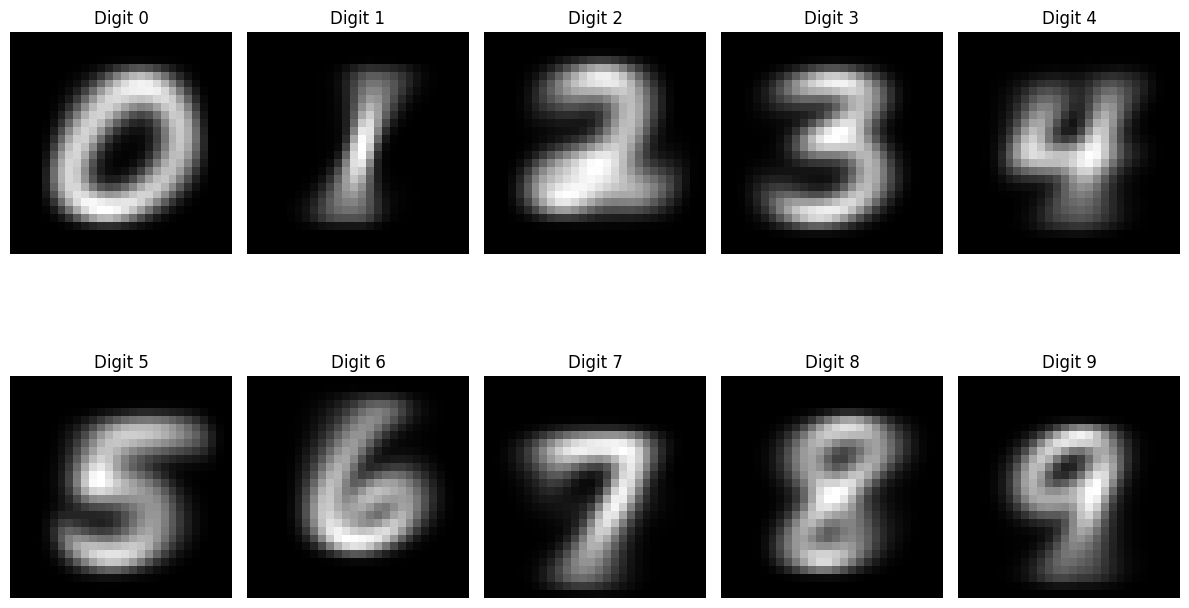

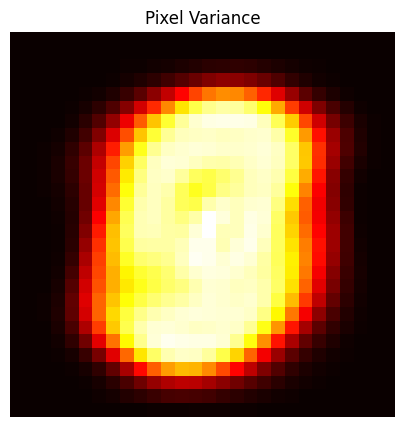

In [ ]:
#Average Digit per Class
plt.figure(figsize=(12,8))

for digit in range(10):
    digit_images = x_train[y_train == digit]
    mean_digit = np.mean(digit_images, axis=0)

    plt.subplot(2,5,digit+1)
    plt.imshow(mean_digit, cmap='gray')
    plt.title(f"Digit {digit}")
    plt.axis('off')

plt.tight_layout()
plt.show()
#Purpose
#Shows the “average appearance” of each digit.

#Variance Across Pixels
variance_image = np.var(x_train, axis=0)

plt.figure(figsize=(5,5))
plt.imshow(variance_image, cmap='hot')

plt.title("Pixel Variance")
plt.axis('off')

plt.show()
#Interpretation
#* Bright areas = highly changing pixels
#* Dark areas = mostly constant pixels

# ADD ANY OTHER DATA EXPLORATION YOU GOT

#Data Transformation
##Preprocessing  

To ensure stable optimization, optimal learning trajectories, and compatibility across models.

* An initial class distribution plot revealed the classes are uniformly distributed without severe class imbalances.
* Based on pixel intensity histogram; the raw intensities strongly positively skewed, indicating that normalization was required.



####Normalization:
* Pixel intensity values across all images were converted from their original [0, 255] range to a normalized scale of [0, 1] by dividing each pixel value by 255. This bounds intensity distributions and prevents high pixel values from dominating optimizations.



####Reshaping and Flattening:

* For vector-input architectures (Classification Random Forest and Support Vector Machine), each 28 x 28 matrix was flattened into a 1D feature array consisting of 784 features.
* For matrix-input architectures,
Regularised CNN and Standard CNN:
Images were reshaped to include an explicit channel dimension (28 x times 28 x 28 x1) to accommodate structural requirements of convolutional layers.

#Models

## Order of Models
1. Support Vector Machine
2. CNN
3. CNN with Regularization techniques
4. Classification Random Forest

###1. SMV

Loading data...
Train shape: (60000, 784)
Test shape:  (10000, 784)
Train: (54000, 784) | Val: (6000, 784) | Test: (10000, 784)
Testing → C=0.01, lr=0.001
  Training classifier for digit 0...
  Training classifier for digit 1...
  Training classifier for digit 2...
  Training classifier for digit 3...
  Training classifier for digit 4...
  Training classifier for digit 5...
  Training classifier for digit 6...
  Training classifier for digit 7...
  Training classifier for digit 8...
  Training classifier for digit 9...
  Val accuracy: 0.8753

Testing → C=0.01, lr=0.01
  Training classifier for digit 0...
  Training classifier for digit 1...
  Training classifier for digit 2...
  Training classifier for digit 3...
  Training classifier for digit 4...
  Training classifier for digit 5...
  Training classifier for digit 6...
  Training classifier for digit 7...
  Training classifier for digit 8...
  Training classifier for digit 9...
  Val accuracy: 0.7877

Testing → C=0.1, lr=0.001
  Tra

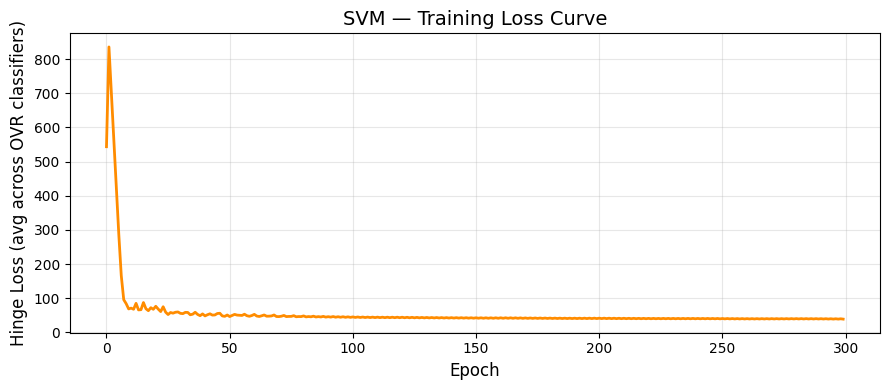


  SVM — Test Accuracy: 0.8986
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       980
           1       0.95      0.99      0.97      1135
           2       0.93      0.89      0.91      1032
           3       0.92      0.88      0.90      1010
           4       0.89      0.90      0.90       982
           5       0.80      0.89      0.84       892
           6       0.92      0.96      0.94       958
           7       0.92      0.90      0.91      1028
           8       0.93      0.70      0.80       974
           9       0.82      0.89      0.85      1009

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



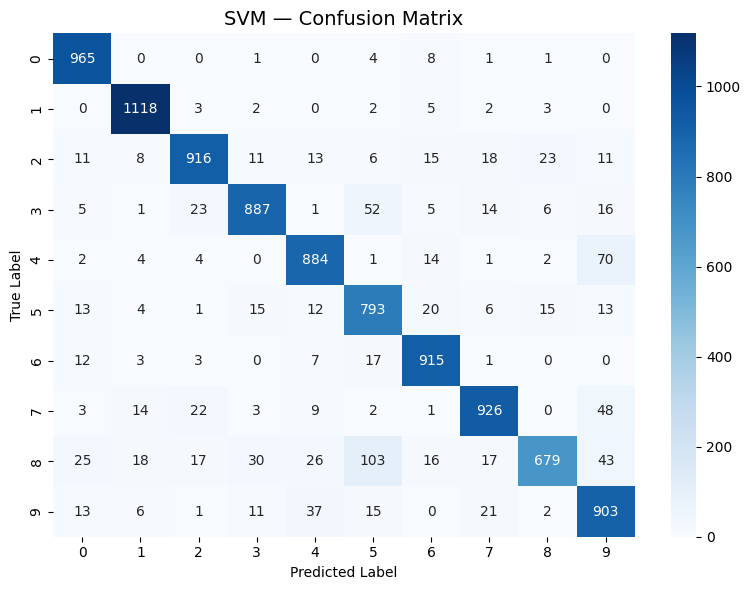

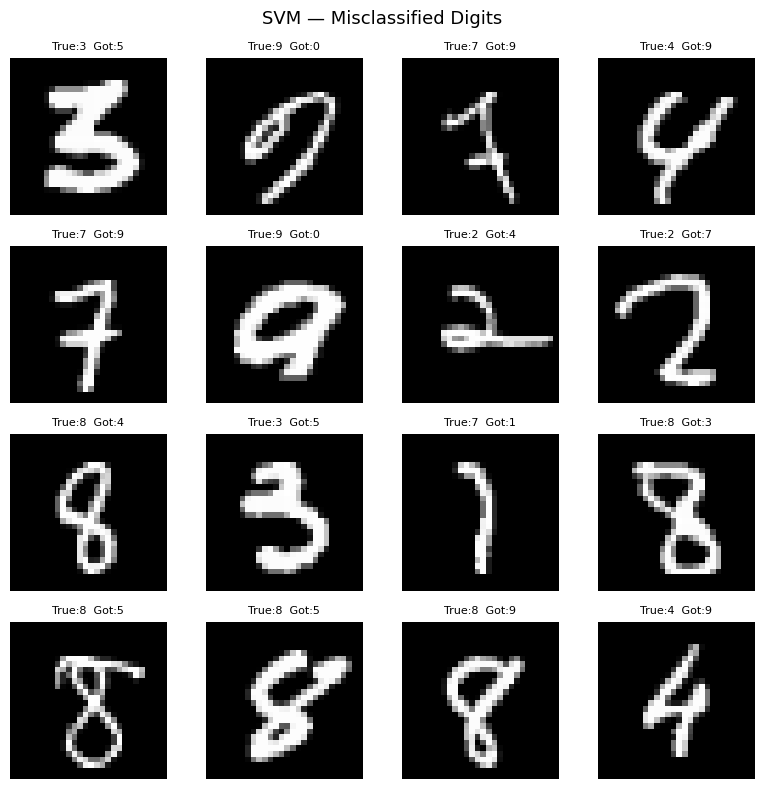

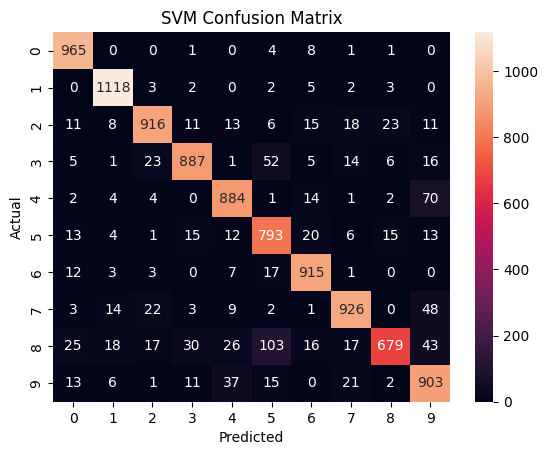

In [ ]:
#SMV
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

class SVMScratch:
    def __init__(self, C=1.0, lr=0.001, epochs=200):
        self.C = C
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
        self.loss_history = []
        y_ = np.where(y == 1, 1, -1).astype(float)
        for _ in range(self.epochs):
            margins = y_ * (X @ self.w + self.b)
            mask = margins < 1
            dw = self.w - self.C * (X[mask] * y_[mask, None]).sum(axis=0)
            db = -self.C * y_[mask].sum()
            self.w -= self.lr * dw
            self.b -= self.lr * db
            hinge = np.maximum(0, 1 - margins).sum()
            loss = 0.5 * np.dot(self.w, self.w) + self.C * hinge
            self.loss_history.append(loss)

    def decision_function(self, X):
        return X @ self.w + self.b


class MulticlassSVMOVR:
    def __init__(self, C=1.0, lr=0.001, epochs=200):
        self.C = C
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.classifiers = {}
        for cls in self.classes_:
            print(f"  Training classifier for digit {cls}...")
            svm = SVMScratch(C=self.C, lr=self.lr, epochs=self.epochs)
            binary_y = (y == cls).astype(int)
            svm.fit(X, binary_y)
            self.classifiers[cls] = svm

    def predict(self, X):
        scores = np.column_stack(
            [self.classifiers[c].decision_function(X) for c in self.classes_]
        )
        return self.classes_[np.argmax(scores, axis=1)]

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

    def get_combined_loss(self)
        all_losses = np.array([self.classifiers[c].loss_history for c in self.classes_])
        return all_losses.mean(axis=0)


(ds_train, ds_test), info = tfds.load(
    'mnist', split=['train', 'test'],
    as_supervised=True, with_info=True
)

def to_numpy(dataset):
    X, y = [], []
    for image, label in tfds.as_numpy(dataset):
        X.append(image.flatten() / 255.0)
        y.append(label)
    return np.array(X), np.array(y)

print("Loading data...")
X_train_full, y_train_full = to_numpy(ds_train)
X_test, y_test = to_numpy(ds_test)
print(f"Train shape: {X_train_full.shape}")
print(f"Test shape:  {X_test.shape}")

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1, random_state=42, stratify=y_train_full
)
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

svm_results = []


X_tune = X_train[:10000]
y_tune = y_train[:10000]

for C in [0.01, 0.1, 1.0]:
    for lr in [0.001, 0.01]:
        print(f"Testing → C={C}, lr={lr}")
        model = MulticlassSVMOVR(C=C, lr=lr, epochs=100)
        model.fit(X_tune, y_tune)
        val_acc = model.accuracy(X_val, y_val)
        svm_results.append({'C': C, 'lr': lr, 'val_acc': val_acc})
        print(f"  Val accuracy: {val_acc:.4f}\n")

best_svm_config = max(svm_results, key=lambda x: x['val_acc'])
print("Best SVM config:", best_svm_config)

print("\nTraining best SVM on full training set...")
svm_model = MulticlassSVMOVR(
    C=best_svm_config['C'],
    lr=best_svm_config['lr'],
    epochs=300
)
svm_model.fit(X_train, y_train)


svm_loss = svm_model.get_combined_loss()

plt.figure(figsize=(9, 4))
plt.plot(svm_loss, color='darkorange', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Hinge Loss (avg across OVR classifiers)', fontsize=12)
plt.title('SVM — Training Loss Curve', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_loss_curve.png', dpi=150)
plt.show()

for name, model in [("SVM", svm_model)]:
    preds = model.predict(X_test)
    acc   = model.accuracy(X_test, y_test)

    print(f"\n{'='*45}")
    print(f"  {name} — Test Accuracy: {acc:.4f}")
    print(f"{'='*45}")
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} — Confusion Matrix', fontsize=14)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'confusion_{name.replace(" ", "_")}.png', dpi=150)
    plt.show()

preds_svm = svm_model.predict(X_test)

wrong_idx_svm = np.where(preds_svm != y_test)[0][:16]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for ax, idx in zip(axes.flat, wrong_idx_svm):
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"True:{y_test[idx]}  Got:{preds_svm[idx]}", fontsize=8)
    ax.axis('off')

plt.suptitle('SVM — Misclassified Digits', fontsize=13)
plt.tight_layout()
plt.savefig('svm_misclassified.png', dpi=150)
plt.show()

y_pred_svm = svm_model.predict(X_test)

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm_svm, annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

###2. Standard CNN

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, callbacks
import json
import itertools
from sklearn.metrics import confusion_matrix, classification_report
import cv2
from PIL import Image
import os

(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()


val_split = int(0.8 * len(train_images))
train_images, val_images = train_images[:val_split], train_images[val_split:]
train_labels, val_labels = train_labels[:val_split], train_labels[val_split:]

train_images = train_images.astype('float32') / 255.0
val_images = val_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

train_images = train_images[..., tf.newaxis]
val_images = val_images[..., tf.newaxis]
test_images = test_images[..., tf.newaxis]

BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

ds_train = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
ds_train = ds_train.cache().shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

ds_val = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
ds_val = ds_val.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

ds_test = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
ds_test = ds_test.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

print(f"Training samples: {len(train_images)}")
print(f"Validation samples: {len(val_images)}")
print(f"Test samples: {len(test_images)}")
print(f"Image shape: {train_images[0].shape}")

Training samples: 48000
Validation samples: 12000
Test samples: 10000
Image shape: (28, 28, 1)


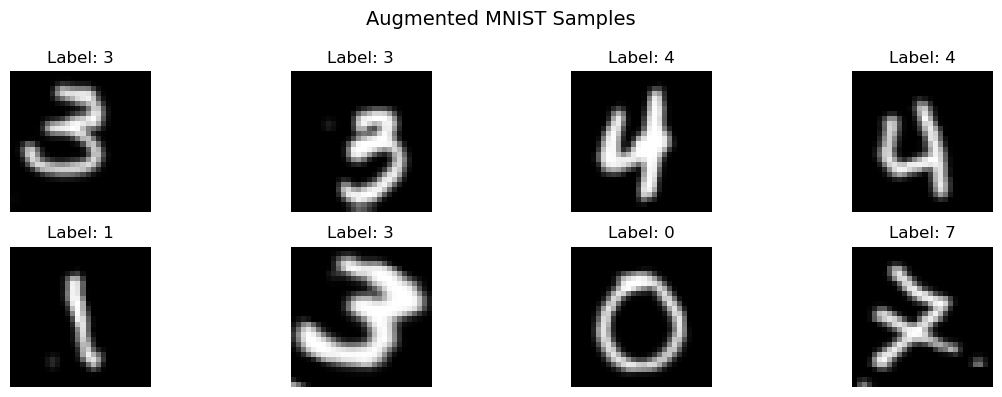

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),          # ±10% rotation
    layers.RandomTranslation(0.1, 0.1),  # ±10% shift
    layers.RandomZoom(0.1),              # ±10% zoom
], name='augmentation')

for images, labels in ds_train.take(1):
    plt.figure(figsize=(12, 4))
    for i in range(8):
        aug = data_augmentation(images[i:i+1], training=True)
        plt.subplot(2, 4, i+1)
        plt.imshow(aug[0].numpy().squeeze(), cmap='gray')
        plt.title(f'Label: {labels[i].numpy()}')
        plt.axis('off')
    plt.suptitle('Augmented MNIST Samples', fontsize=14)
    plt.tight_layout()
    plt.savefig('augmentation_samples.png', dpi=120)
    plt.show()

In [ ]:
def build_improved_cnn(input_shape=(28, 28, 1), num_classes=10):
    inp = layers.Input(shape=input_shape)

    x = data_augmentation(inp)

    # Block 1: 32 filters
    x = layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2: 64 filters
    x = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3: 128 filters with Global Average Pooling
    x = layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    # Classification head
    x = layers.Dense(256, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inp, out, name='ImprovedCNN')

# Build and display model
model_cnn = build_improved_cnn()
model_cnn.summary()

Model: "ImprovedCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ augmentation (Sequential)            │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 324,842 (1.24 MB)

 Trainable params: 323,434 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_cnn.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Model compiled successfully with callbacks")

Model compiled successfully with callbacks


In [ ]:
history_cnn = model_cnn.fit(
    ds_train,
    epochs=30,
    validation_data=ds_val,
    callbacks=callbacks_list,
    verbose=1
)
with open('cnn_history.json', 'w') as f:
    json.dump(history_cnn.history, f)

print("\n Training complete! History saved to cnn_history.json")

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5151 - loss: 1.6088
Epoch 1: val_accuracy improved from None to 0.95325, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 67s 79ms/step - accuracy: 0.7288 - loss: 0.8703 - val_accuracy: 0.9532 - val_loss: 0.1483 - learning_rate: 0.0010
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9263 - loss: 0.2447
Epoch 2: val_accuracy improved from 0.95325 to 0.97283, saving model to best_cnn.keras

Epoch 2: finished saving model to best_cnn.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 75ms/step - accuracy: 0.9335 - loss: 0.2213 - val_accuracy: 0.9728 - val_loss: 0.0913 - learning_rate: 0.0010
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9517 - loss: 0.1657
Epoch 3: val_accuracy improved from 0.97283 to 0.97883, saving model to best_cnn.keras

Epoch 3: finished saving model to best_cnn.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 57s 76ms/step - 

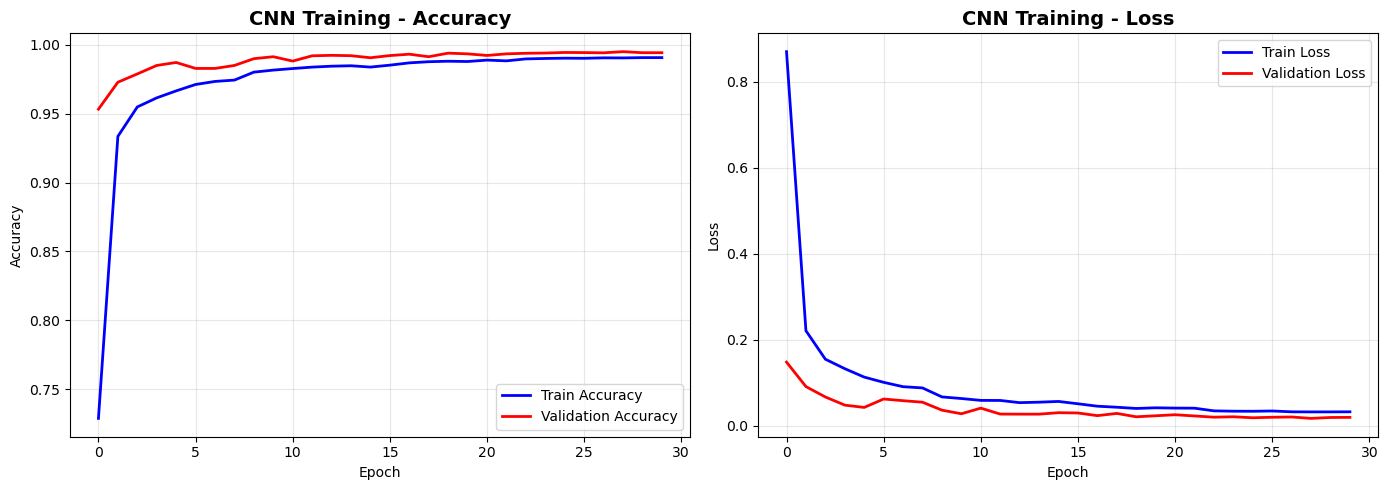


 Best Validation Accuracy: 0.9950 (99.50%)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_cnn.history['accuracy'], 'b-', label='Train Accuracy', linewidth=2)
ax1.plot(history_cnn.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
ax1.set_title('CNN Training - Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_cnn.history['loss'], 'b-', label='Train Loss', linewidth=2)
ax2.plot(history_cnn.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
ax2.set_title('CNN Training - Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print best validation accuracy
best_val_acc = max(history_cnn.history['val_accuracy'])
print(f"\n Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

In [ ]:

test_loss, test_acc = model_cnn.evaluate(ds_test, verbose=1)
print("\n" + "="*50)
print(f" TEST SET RESULTS")
print("="*50)
print(f"Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss      : {test_loss:.4f}")
print("="*50)

y_true, y_pred = [], []
for images, labels in ds_test:
    preds = model_cnn.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('CNN - Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, range(10))
plt.yticks(tick_marks, range(10))

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification report
print("\n Classification Report:")
print("="*50)
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(10)]))


157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9945 - loss: 0.0170

 TEST SET RESULTS
Test Accuracy  : 0.9945 (99.45%)
Test Loss      : 0.0170


###3. Regularised CNN

Original Training Shape: (60000, 28, 28)
Original Testing Shape: (10000, 28, 28)

After Preprocessing
Training Shape: (50000, 28, 28, 1)
Validation Shape: (10000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)
SAMPLE IMAGES


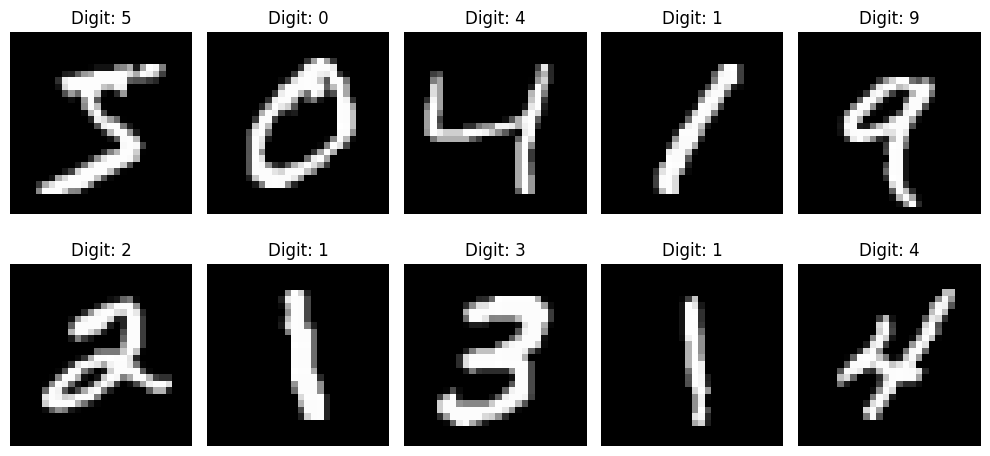

L2 REGULARISATION EXPERIMENT
L2 Lambda=0.0 --> Best Validation Accuracy=0.9845
L2 Lambda=0.0001 --> Best Validation Accuracy=0.9830
L2 Lambda=0.001 --> Best Validation Accuracy=0.9756
L2 Lambda=0.01 --> Best Validation Accuracy=0.9535
 EXPERIMENT RESULTS PLOT


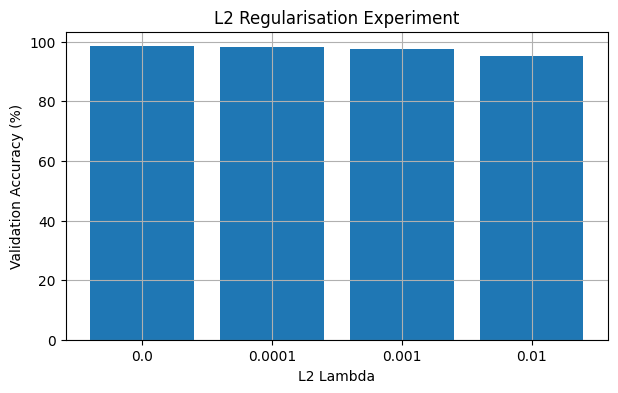

Model: "Regularised_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,701,802 (6.49 MB)

 Trainable params: 1,701,354 (6.49 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8984 - loss: 0.8228
Epoch 1: val_accuracy improved from None to 0.97510, saving model to outputs/best_regularised_model.keras

Epoch 1: finished saving model to outputs/best_regularised_model.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 147s 184ms/step - accuracy: 0.9510 - loss: 0.5619 - val_accuracy: 0.9751 - val_loss: 0.3535 - learning_rate: 5.0000e-04
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9767 - loss: 0.3224
Epoch 2: val_accuracy improved from 0.97510 to 0.98640, saving model to outputs/best_regularised_model.keras

Epoch 2: finished saving model to outputs/best_regularised_model.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 181ms/step - accuracy: 0.9783 - loss: 0.2891 - val_accuracy: 0.9864 - val_loss: 0.2174 - learning_rate: 5.0000e-04
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9803 - loss: 0.2169
Epoch 3: val_accuracy did not improve from 0.98640
782/782 ━━━━━━━━━━━━━━━━━━━━

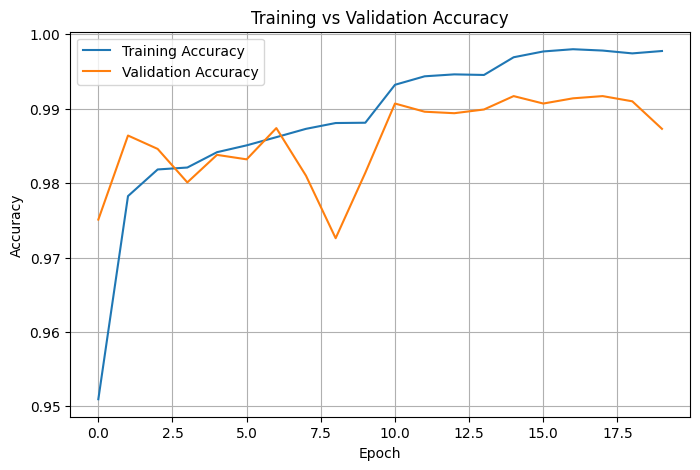

TRAINIG LOSS PLOT


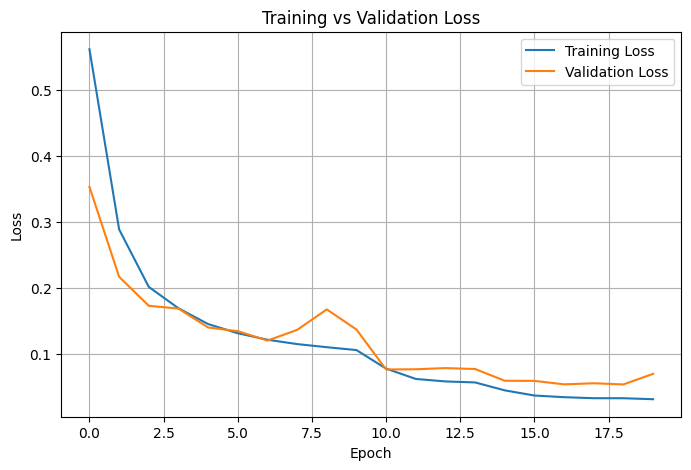

FINAL TEST RESULTS
Test Loss     : 0.0510
Test Accuracy : 0.9917
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      1.00      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

Precision : 0.9917
Recall    : 0.9917
F1-Score  : 0.9917


<Figure size 800x800 with 0 Axes>

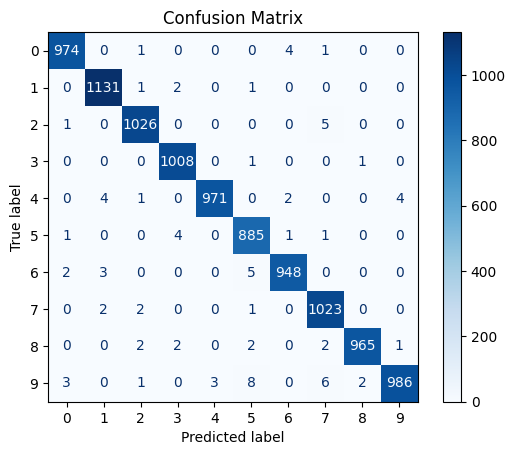

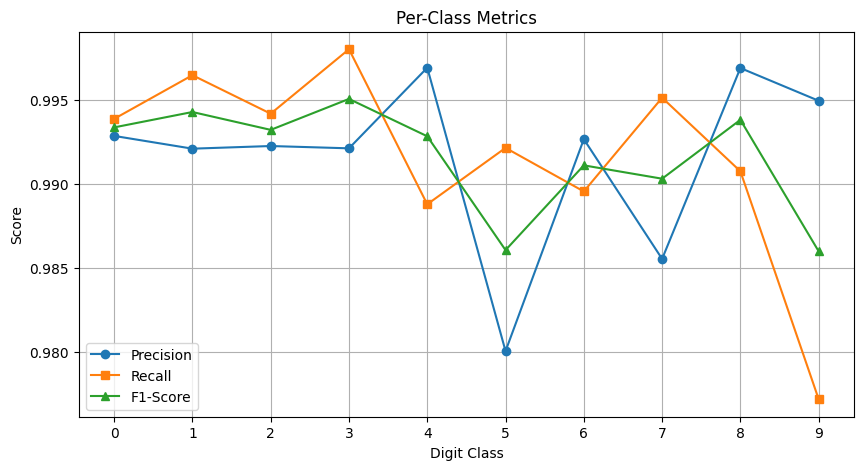

SAMPLE PREDICTIONS


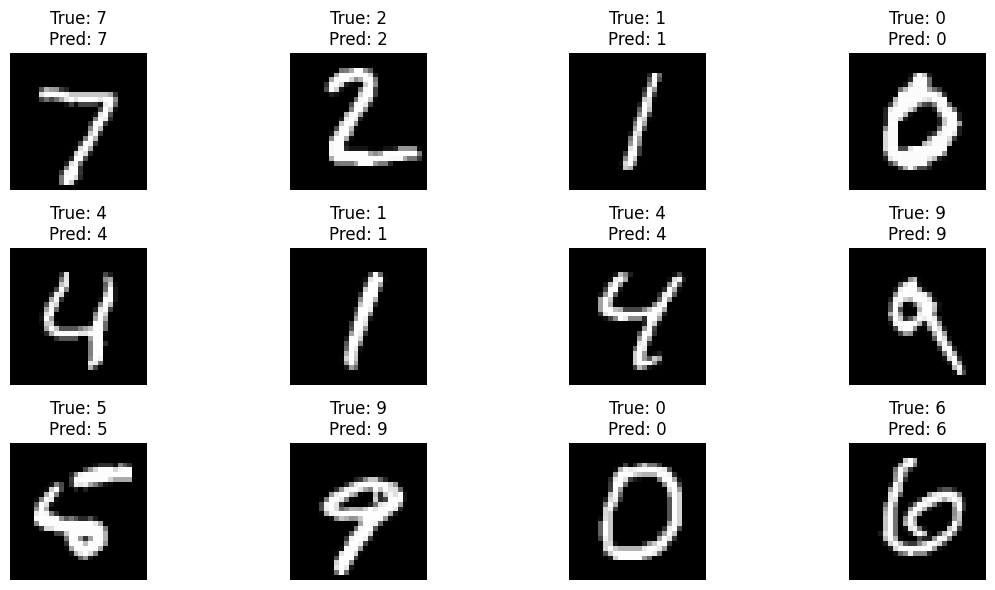


Training and Evaluation Complete.


In [ ]:
# REGULARISED CNN FOR MNIST

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Activation,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)



SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

LEARNING_RATE = 5e-4
BATCH_SIZE = 64
EPOCHS = 20
DROPOUT_RATE = 0.4
L2_LAMBDA = 1e-3

SAVE_DIR = "outputs"
os.makedirs(SAVE_DIR, exist_ok=True)


(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Original Training Shape:", X_train.shape)
print("Original Testing Shape:", X_test.shape)

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

X_val = X_train[-10000:]
y_val = y_train[-10000:]

X_train = X_train[:-10000]
y_train = y_train[:-10000]

y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_val_cat = tf.keras.utils.to_categorical(y_val, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

print("\nAfter Preprocessing")
print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Testing Shape:", X_test.shape)

print("SAMPLE IMAGES")
print("================================================")
plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


lambdas = [0.0, 1e-4, 1e-3, 1e-2]
results = []

print("L2 REGULARISATION EXPERIMENT")
print("================================================")

for lam in lambdas:

    temp_model = Sequential()

    temp_model.add(Input(shape=(28, 28, 1)))

    temp_model.add(
        Conv2D(
            32,
            (3, 3),
            padding="same",
            kernel_regularizer=regularizers.l2(lam)
        )
    )

    temp_model.add(Activation("relu"))
    temp_model.add(MaxPooling2D((2, 2)))

    temp_model.add(Flatten())

    temp_model.add(
        Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(lam)
        )
    )

    temp_model.add(Dense(10, activation="softmax"))

    temp_model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_temp = temp_model.fit(
        X_train,
        y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=5,
        batch_size=64,
        verbose=0
    )

    best_acc = max(history_temp.history["val_accuracy"])

    results.append(best_acc)

    print(f"L2 Lambda={lam} --> Best Validation Accuracy={best_acc:.4f}")

print(" EXPERIMENT RESULTS PLOT")
print("===============================================")
plt.figure(figsize=(7, 4))

plt.bar(
    [str(l) for l in lambdas],
    [r * 100 for r in results]
)

plt.xlabel("L2 Lambda")
plt.ylabel("Validation Accuracy (%)")
plt.title("L2 Regularisation Experiment")
plt.grid(True)

plt.show()

#
# BUILD FINAL CNN MODEL

model = Sequential(name="Regularised_CNN")

model.add(Input(shape=(28, 28, 1)))


model.add(
    Conv2D(
        32,
        (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(L2_LAMBDA),
        use_bias=False
    )
)

model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D((2, 2)))



model.add(
    Conv2D(
        64,
        (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(L2_LAMBDA),
        use_bias=False
    )
)

model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D((2, 2)))

model.add(
    Conv2D(
        128,
        (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(L2_LAMBDA),
        use_bias=False
    )
)

model.add(BatchNormalization())
model.add(Activation("relu"))


model.add(Flatten())

model.add(
    Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_LAMBDA)
    )
)

model.add(Dropout(DROPOUT_RATE))

model.add(Dense(10, activation="softmax"))


# COMPILE MODEL


model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

checkpoint_path = os.path.join(
    SAVE_DIR,
    "best_regularised_model.keras"
)

callbacks = [

    ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print("TRAINIG ACCURACY PLOT")
print("================================================")

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# PLOT TRAINING LOSS
print("TRAINIG LOSS PLOT")
print("================================================")

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

loss, accuracy = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)


print("FINAL TEST RESULTS")
print("================================================")

print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)


print("CLASSIFICATION REPORT")
print("================================================")

print(classification_report(y_test, y_pred))

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")


# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix")

plt.show()

precision_per_class = precision_score(
    y_test,
    y_pred,
    average=None
)

recall_per_class = recall_score(
    y_test,
    y_pred,
    average=None
)

f1_per_class = f1_score(
    y_test,
    y_pred,
    average=None
)

classes = np.arange(10)

plt.figure(figsize=(10, 5))

plt.plot(
    classes,
    precision_per_class,
    marker='o',
    label="Precision"
)

plt.plot(
    classes,
    recall_per_class,
    marker='s',
    label="Recall"
)

plt.plot(
    classes,
    f1_per_class,
    marker='^',
    label="F1-Score"
)

plt.xticks(classes)

plt.xlabel("Digit Class")
plt.ylabel("Score")

plt.title("Per-Class Metrics")

plt.legend()
plt.grid(True)

plt.show()

print("SAMPLE PREDICTIONS")
print("================================================")
plt.figure(figsize=(12, 6))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    plt.title(
        f"True: {y_test[i]}\nPred: {y_pred[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

print("\nTraining and Evaluation Complete.")

###4. Random Forest Classifier

Empirical class frequency distribution of the handwritten digits within the MNIST benchmark dataset


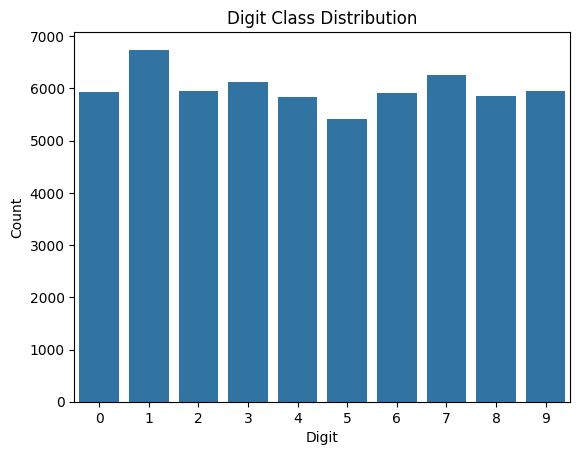

Frequency distribution histogram of raw pixel intensities across the MNIST handwritten image collection


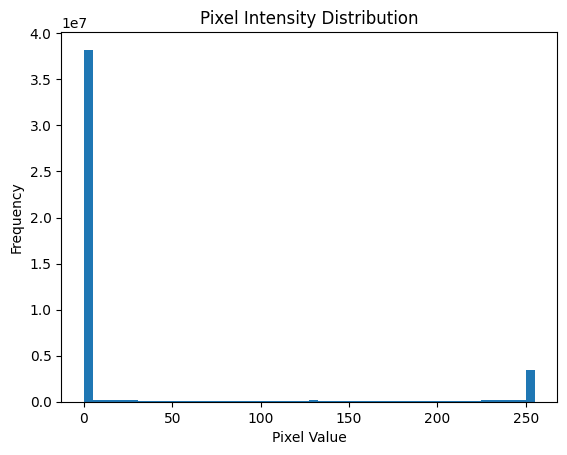

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Accuracy: 0.965
Performance Metrics
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.96      1032
           3       0.95      0.96      0.95      1010
           4       0.97      0.96      0.97       982
           5       0.97      0.95      0.96       892
           6       0.97      0.98      0.97       958
           7       0.97      0.95      0.96      1028
           8       0.96      0.95      0.95       974
           9       0.95      0.95      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.97      0.96      0.96     10000



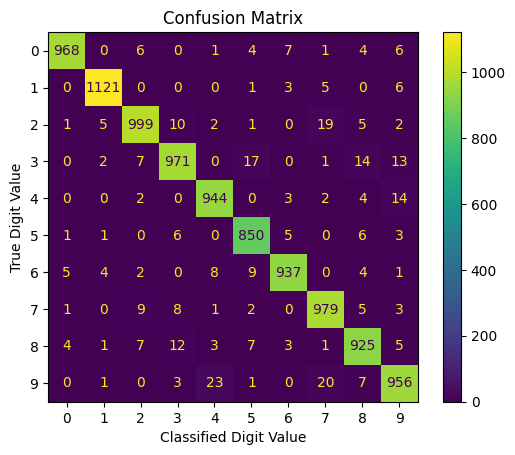

In [ ]:
print("Empirical class frequency distribution of the handwritten digits within the MNIST benchmark dataset")
print("================================================")
cntplot = sns.countplot(x=y_train)
plt.title("Digit Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

print("Frequency distribution histogram of raw pixel intensities across the MNIST handwritten image collection")
print("================================================")
plt.hist(x_train.ravel(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

X_train = x_train.astype("float32") / 255.0
X_test = x_test.astype("float32") / 255.0

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train_flat, y_train)

best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test_flat)


print("Best Parameters:", random_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

cn = confusion_matrix(y_pred, y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cn)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Classified Digit Value")
ax.set_ylabel("True Digit Value")

print("Performance Metrics")
print("================================================")
print(classification_report(y_test, y_pred))